<a href="https://colab.research.google.com/github/shadi159/Final-Project-Mathematics/blob/main/code_KTH_TIPS.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# KTH-TIPS Texture Classification — Spectral + Classical Features
Converted from DTD pipeline. KTH-TIPS has **10 material categories**, each with images taken at multiple scales and illumination conditions.

Expected dataset structure:
```
KTH-TIPS/
├── aluminium_foil/
├── brown_bread/
├── corduroy/
├── cork/
├── cotton/
├── cracker/
├── lettuce_leaf/
├── monkeyTree/
├── sandpaper/
└── wood/
```

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


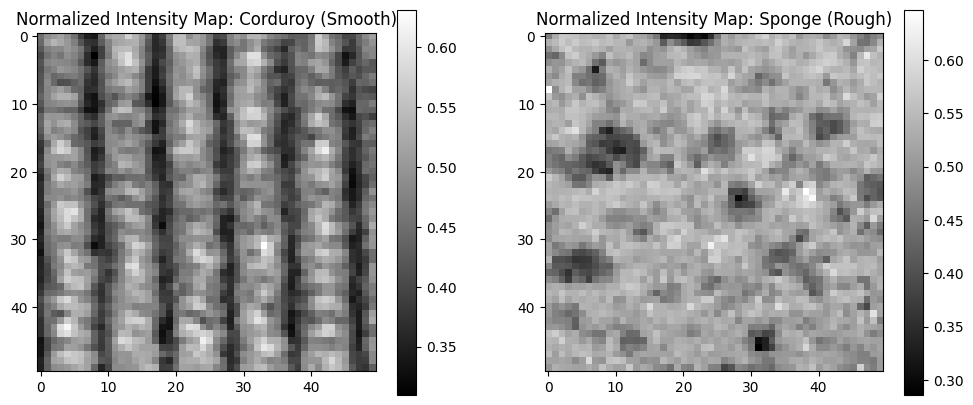

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix, diags, eye
from scipy.sparse.linalg import eigsh, expm_multiply

def create_image_laplacian(img_path, sigma=0.05, n_size=50):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (n_size, n_size))
    h, w = img.shape
    n = h * w
    pixels = img.flatten().astype(float) / 255.0

    rows, cols, data = [], [], []
    for y in range(h):
        for x in range(w):
            idx = y * w + x
            for dy in [-1, 0, 1]:
                for dx in [-1, 0, 1]:
                    if dy == 0 and dx == 0: continue
                    ny, nx = y + dy, x + dx
                    if 0 <= ny < h and 0 <= nx < w:
                        neighbor_idx = ny * w + nx
                        diff = (pixels[idx] - pixels[neighbor_idx])**2
                        weight = np.exp(-diff / (2 * sigma**2))
                        rows.append(idx)
                        cols.append(neighbor_idx)
                        data.append(weight)

    W = csr_matrix((data, (rows, cols)), shape=(n, n))
    degrees = np.array(W.sum(axis=1)).flatten()
    d_inv_sqrt = np.zeros_like(degrees)
    mask = degrees > 0
    d_inv_sqrt[mask] = np.power(degrees[mask], -0.5)
    D_inv_sqrt = diags(d_inv_sqrt)
    L_norm = eye(n) - D_inv_sqrt @ W @ D_inv_sqrt
    L_norm = L_norm + eye(n) * 1e-6
    return L_norm, img, pixels.reshape((h, w))

# ---- Visualization on two KTH-TIPS images (smooth vs rough texture) ----
# Replace these paths with two actual images from your KTH-TIPS folder
KTH_ROOT = "/content/drive/My Drive/Final Project (Applied mathmatic)/KTH-TIPS"

img_smooth_path = f"{KTH_ROOT}/corduroy/42-scale_1_im_1_grey.png"   # smooth texture example
img_rough_path  = f"{KTH_ROOT}/sponge/21-scale_1_im_1_grey.png" # rough texture example

L_smooth, _, intensity_smooth = create_image_laplacian(img_smooth_path)
L_rough,  _, intensity_rough  = create_image_laplacian(img_rough_path)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(intensity_smooth, cmap='gray')
plt.title('Normalized Intensity Map: Corduroy (Smooth)')
plt.colorbar()

plt.subplot(1, 2, 2)
plt.imshow(intensity_rough, cmap='gray')
plt.title('Normalized Intensity Map: Sponge (Rough)')
plt.colorbar()
plt.show()

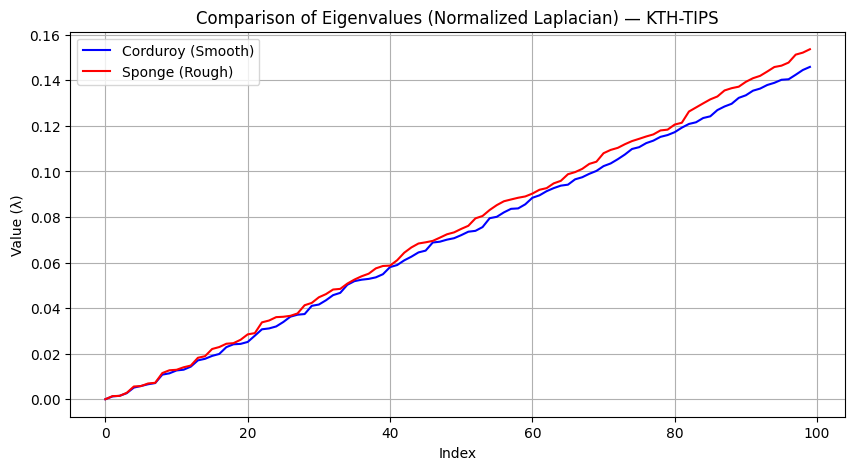

In [ ]:
# --- Eigenvalue comparison (Spectral Signature) ---
k = 100
ev_smooth, _ = eigsh(L_smooth, k=k, which='SM')
ev_rough,  _ = eigsh(L_rough,  k=k, which='SM')

plt.figure(figsize=(10, 5))
plt.plot(ev_smooth, 'b-', label='Corduroy (Smooth)')
plt.plot(ev_rough,  'r-', label='Sponge (Rough)')
plt.title('Comparison of Eigenvalues (Normalized Laplacian) — KTH-TIPS')
plt.xlabel('Index')
plt.ylabel('Value (λ)')
plt.legend()
plt.grid(True)
plt.show()

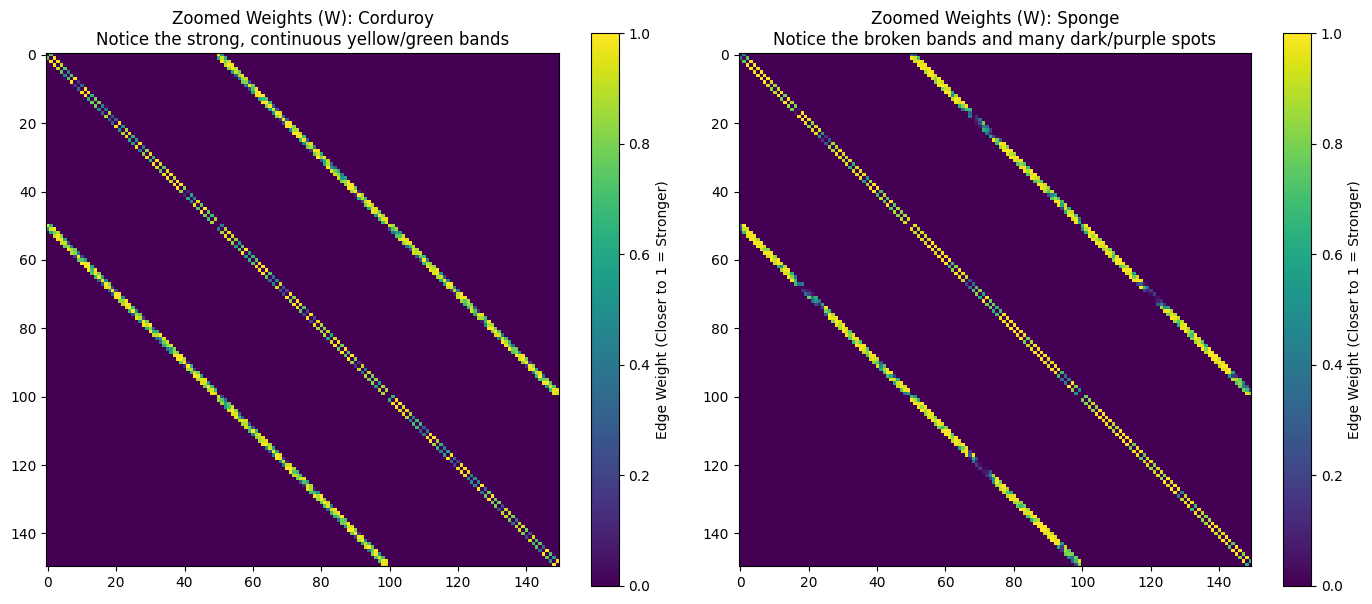

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from scipy.sparse import csr_matrix

# פונקציה ייעודית להמחשה שמחזירה רק את מטריצת המשקלים W
def get_weight_matrix(img_path, sigma=0.1, n_size=50):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise ValueError(f"Could not read image at {img_path}")

    img = cv2.resize(img, (n_size, n_size))
    h, w = img.shape
    n = h * w
    pixels = img.flatten().astype(float) / 255.0

    rows, cols, data = [], [], []
    for y in range(h):
        for x in range(w):
            idx = y * w + x
            for dy in [-1, 0, 1]:
                for dx in [-1, 0, 1]:
                    if dy == 0 and dx == 0: continue
                    ny, nx = y + dy, x + dx
                    if 0 <= ny < h and 0 <= nx < w:
                        neighbor_idx = ny * w + nx
                        diff = (pixels[idx] - pixels[neighbor_idx])**2
                        weight = np.exp(-diff / (2 * sigma**2))
                        rows.append(idx)
                        cols.append(neighbor_idx)
                        data.append(weight)

    W = csr_matrix((data, (rows, cols)), shape=(n, n))
    return W

# ==========================================
# הרצה והצגת ה"זום-אין"
# ==========================================

KTH_ROOT = "/content/drive/My Drive/Final Project (Applied mathmatic)/KTH-TIPS"

# ודא שהנתיבים האלו תקינים אצלך בדרייב
img_smooth_path = f"{KTH_ROOT}/corduroy/42-scale_1_im_1_grey.png"   # smooth texture example
img_rough_path  = f"{KTH_ROOT}/sponge/21-scale_1_im_1_grey.png" # rough texture example

# 1. משיכת מטריצות המשקלים
W_smooth = get_weight_matrix(img_smooth_path, sigma=0.05, n_size=50) # סיגמה נמוכה מדגישה הבדלים
W_rough  = get_weight_matrix(img_rough_path, sigma=0.05, n_size=50)

# 2. חיתוך בלוק של 150x150 כדי לראות את הרזולוציה מקרוב
zoom_size = 150
W_smooth_zoomed = W_smooth.toarray()[:zoom_size, :zoom_size]
W_rough_zoomed  = W_rough.toarray()[:zoom_size, :zoom_size]

# 3. ציור
plt.figure(figsize=(14, 6))

# קורדרוי
plt.subplot(1, 2, 1)
plt.imshow(W_smooth_zoomed, cmap='viridis', interpolation='none')
plt.colorbar(label='Edge Weight (Closer to 1 = Stronger)')
plt.title('Zoomed Weights (W): Corduroy\nNotice the strong, continuous yellow/green bands')

# ספוג
plt.subplot(1, 2, 2)
plt.imshow(W_rough_zoomed, cmap='viridis', interpolation='none')
plt.colorbar(label='Edge Weight (Closer to 1 = Stronger)')
plt.title('Zoomed Weights (W): Sponge\nNotice the broken bands and many dark/purple spots')

plt.tight_layout()
plt.show()

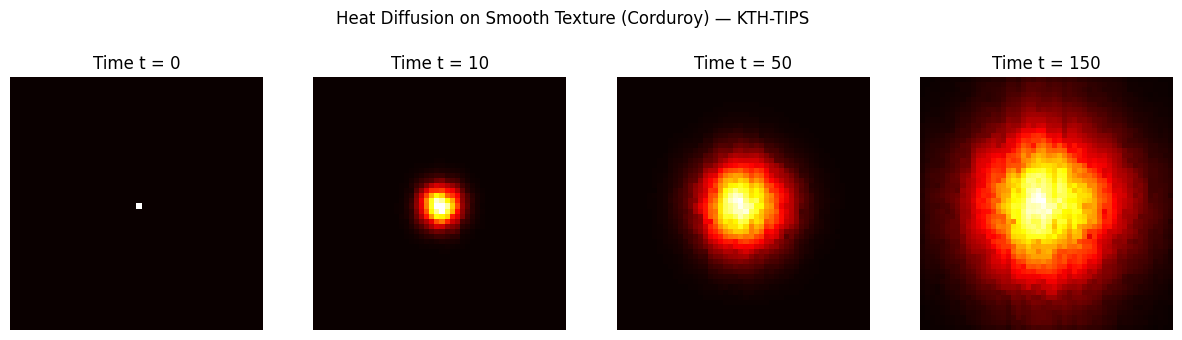

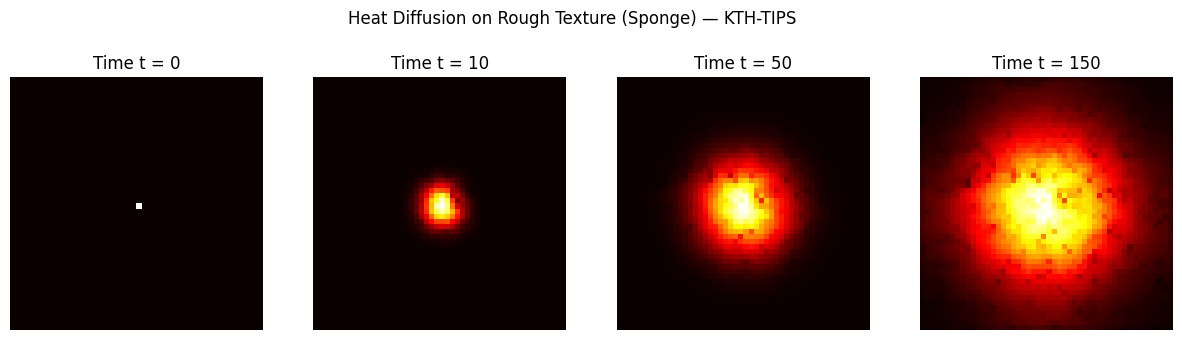

In [ ]:
# --- Heat Diffusion Simulation ---
def simulate_heat(L, title, size=50):
    n = size * size
    h0 = np.zeros(n)
    h0[n // 2 + size // 2] = 1.0

    times = [0, 10, 50, 150]
    fig, axes = plt.subplots(1, 4, figsize=(15, 4))
    for i, t in enumerate(times):
        ht = expm_multiply(-L, h0, start=0, stop=t, num=2)[-1]
        axes[i].imshow(ht.reshape((size, size)), cmap='hot')
        axes[i].set_title(f'Time t = {t}')
        axes[i].axis('off')
    plt.suptitle(title)
    plt.show()

simulate_heat(L_smooth, 'Heat Diffusion on Smooth Texture (Corduroy) — KTH-TIPS')
simulate_heat(L_rough,  'Heat Diffusion on Rough Texture (Sponge) — KTH-TIPS')

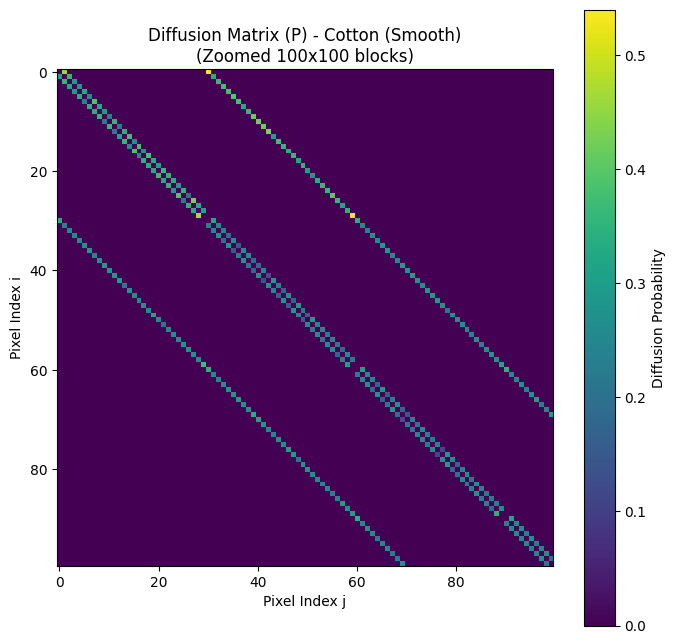

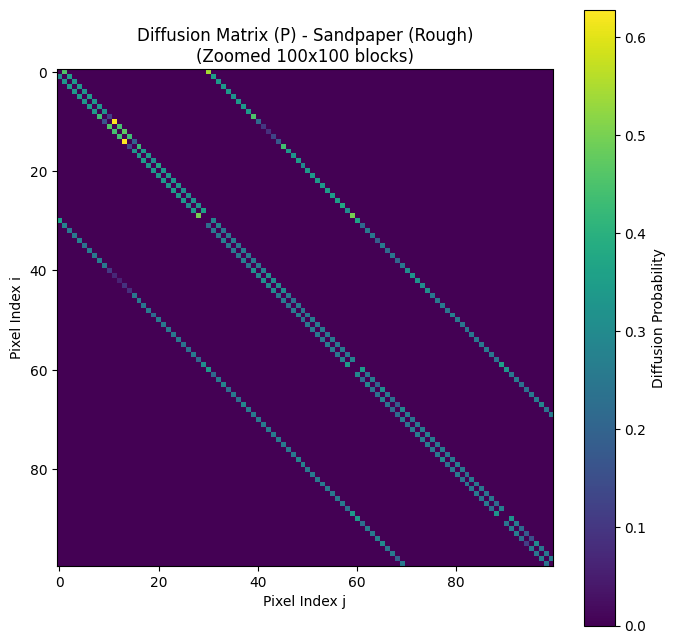

In [ ]:
# --- Diffusion Matrix (Transition Matrix P = D^-1 * W) ---
def plot_diffusion_matrix(img_path, title, sigma=0.1, n_size=30):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (n_size, n_size))
    h, w = img.shape
    n = h * w
    pixels = img.flatten().astype(float) / 255.0

    rows, cols, data = [], [], []
    for y in range(h):
        for x in range(w):
            idx = y * w + x
            for dy, dx in [(-1,0), (1,0), (0,-1), (0,1)]:
                ny, nx = y + dy, x + dx
                if 0 <= ny < h and 0 <= nx < w:
                    neighbor_idx = ny * w + nx
                    diff = (pixels[idx] - pixels[neighbor_idx])**2
                    weight = np.exp(-diff / (2 * sigma**2))
                    rows.append(idx)
                    cols.append(neighbor_idx)
                    data.append(weight)

    W = csr_matrix((data, (rows, cols)), shape=(n, n))
    degrees = np.array(W.sum(axis=1)).flatten()
    d_inv = np.zeros_like(degrees)
    mask = degrees > 0
    d_inv[mask] = 1.0 / degrees[mask]
    P = diags(d_inv) @ W

    plt.figure(figsize=(8, 8))
    plt.imshow(P.toarray()[:100, :100], cmap='viridis')
    plt.colorbar(label='Diffusion Probability')
    plt.title(f'Diffusion Matrix (P) - {title}\n(Zoomed 100x100 blocks)')
    plt.xlabel('Pixel Index j')
    plt.ylabel('Pixel Index i')
    plt.show()

plot_diffusion_matrix(img_smooth_path, 'Corduroy (Smooth)')
plot_diffusion_matrix(img_rough_path,  'Sponge (Rough)')

In [ ]:
print(f"Corduroy spectral energy:    {np.mean(ev_smooth)}")
print(f"Sponge spectral energy: {np.mean(ev_rough)}")

Corduroy spectral energy:    0.07180737827973908
Sponge spectral energy: 0.07503112018268268


In [ ]:
def get_spectral_signature(img_path, k=100):
    try:
        L_norm, _, _ = create_image_laplacian(img_path, sigma=0.1, n_size=50)
        eigenvalues, _ = eigsh(L_norm, k=k, which='SM')
        return eigenvalues
    except Exception as e:
        print(f"Error processing {img_path}: {e}")
        return None

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import os

# KTH-TIPS is a flat folder dataset: KTH_ROOT/<category>/<image>.png
# No official train/val/test split files — we use random stratified split
def prepare_spectral_features_kth(dataset_path, num_k=100):
    X = []
    y = []

    categories = sorted([d for d in os.listdir(dataset_path)
                         if os.path.isdir(os.path.join(dataset_path, d))])
    label_map = {cat: i for i, cat in enumerate(categories)}
    print(f"KTH-TIPS Mapping ({len(categories)} classes): {label_map}")

    for category in categories:
        cat_path = os.path.join(dataset_path, category)
        for img_name in os.listdir(cat_path):
            if img_name.lower().endswith(('.png', '.jpg', '.jpeg')):
                img_path = os.path.join(cat_path, img_name)
                features = get_spectral_signature(img_path, k=num_k)
                if features is not None:
                    X.append(features)
                    y.append(label_map[category])

    return torch.tensor(np.array(X), dtype=torch.float32), torch.tensor(y, dtype=torch.long)

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from scipy.sparse.linalg import eigsh
from scipy.linalg import eigh
import os

# ============================================================
# Phase A: Multi-scale spectral signature
# ============================================================
def get_multiscale_signature(img_path, k=50, n_size=64):
    sigmas = [0.05, 0.1, 0.3]
    all_features = []

    for sigma in sigmas:
        try:
            L_norm, _, _ = create_image_laplacian(img_path, sigma=sigma, n_size=n_size)
            eigenvalues, _ = eigsh(L_norm, k=k, which='SM', maxiter=5000, ncv=3*k)
            eigenvalues = np.sort(eigenvalues)

            stats = np.array([
                np.mean(eigenvalues),
                np.std(eigenvalues),
                np.median(eigenvalues),
                np.percentile(eigenvalues, 25),
                np.percentile(eigenvalues, 75),
                eigenvalues[1] if len(eigenvalues) > 1 else 0,  # Fiedler value
            ])
            all_features.append(np.concatenate([eigenvalues, stats]))
        except Exception:
            try:
                L_dense = L_norm.toarray()
                eigenvalues = eigh(L_dense, eigvals=(0, k-1), eigvals_only=True)
                eigenvalues = np.sort(eigenvalues)
                stats = np.array([
                    np.mean(eigenvalues),
                    np.std(eigenvalues),
                    np.median(eigenvalues),
                    np.percentile(eigenvalues, 25),
                    np.percentile(eigenvalues, 75),
                    eigenvalues[1] if len(eigenvalues) > 1 else 0,
                ])
                all_features.append(np.concatenate([eigenvalues, stats]))
            except:
                eigenvalues = np.linspace(0, 1, k)

    return np.concatenate(all_features)  # 3 × (50+6) = 168 features

# ============================================================
# Phase B: Dataset preparation with cache (KTH-TIPS)
# KTH-TIPS has no official split files — all images live in
# category folders. We scan them all and do a random split later.
# ============================================================
def prepare_kth_with_cache(kth_root, k=50, n_size=64,
                            cache_path="/content/drive/My Drive/Final Project (Applied mathmatic)/kth_features.npz"):

    categories = sorted([d for d in os.listdir(kth_root)
                         if os.path.isdir(os.path.join(kth_root, d))])
    label_map = {cat: i for i, cat in enumerate(categories)}

    # Collect all image paths relative to kth_root
    all_image_paths = []
    for cat in categories:
        cat_path = os.path.join(kth_root, cat)
        for fname in os.listdir(cat_path):
            if fname.lower().endswith(('.png', '.jpg', '.jpeg')):
                all_image_paths.append(os.path.join(cat, fname))  # relative path

    X, y, processed_paths = [], [], []
    if os.path.exists(cache_path):
        data = np.load(cache_path, allow_pickle=True)
        X = list(data['X'])
        y = list(data['y'])
        processed_paths = list(data['processed_paths'])
        print(f"Resuming from cache: {len(X)} samples found.")

    remaining_tasks = [p for p in all_image_paths if p not in processed_paths]
    expected_dim = k * 3 + 18  # 3 sigmas × (k eigenvalues + 6 stats)

    if remaining_tasks:
        print(f"Starting extraction for {len(remaining_tasks)} images...")
        for i, rel_path in enumerate(remaining_tasks):
            if i % 10 == 0:
                print(f"  Attempting image {i+1}/{len(remaining_tasks)}: {rel_path}")

            full_path = os.path.join(kth_root, rel_path)
            feat = get_multiscale_signature(full_path, k=k, n_size=n_size)
            cat_name = rel_path.split(os.sep)[0]

            if feat is not None and len(feat) == expected_dim:
                X.append(feat)
                y.append(label_map[cat_name])
                processed_paths.append(rel_path)
            else:
                print(f"  [!] Failed or skipped: {rel_path}")
                processed_paths.append(rel_path)
                X.append(np.zeros(expected_dim))
                y.append(label_map[cat_name])

            if len(processed_paths) % 100 == 0:
                np.savez(cache_path, X=np.array(X, dtype=float), y=np.array(y),
                         categories=np.array(categories),
                         processed_paths=np.array(processed_paths))
                print(f"  >>> Checkpoint saved at {len(processed_paths)} images.")

    np.savez(cache_path, X=np.array(X, dtype=float), y=np.array(y),
             categories=np.array(categories),
             processed_paths=np.array(processed_paths))

    return (torch.tensor(np.array(X, dtype=float), dtype=torch.float32),
            torch.tensor(y, dtype=torch.long),
            categories)

# ============================================================
# Phase C: Neural Network — 10 classes for KTH-TIPS
# ============================================================
class TextureSpectralNet(nn.Module):
    def __init__(self, input_size, num_classes=10):  # KTH-TIPS has 10 categories
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.network(x)

# ============================================================
# Phase D: Full training pipeline for KTH-TIPS
# Uses random stratified 80/20 split (no official splits in KTH-TIPS)
# ============================================================
def train_model_kth(dataset_path, k=50, n_size=48, epochs=150):
    print(f"Image size: {n_size}x{n_size}")
    print("=== Phase 1: Feature Extraction ===")
    X, y, categories = prepare_kth_with_cache(dataset_path, k=k, n_size=n_size)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X.numpy())
    X = torch.tensor(X_scaled, dtype=torch.float32)

    num_classes = len(categories)
    feature_dim = X.shape[1]
    print(f"Samples: {len(X)} | Classes: {num_classes} | Features: {feature_dim}")

    # KTH-TIPS: random 80/20 stratified split
    X_tr, X_te, y_tr, y_te = train_test_split(
        X.numpy(), y.numpy(),
        test_size=0.2,
        random_state=42,
        stratify=y.numpy()
    )
    print(f"Train: {len(X_tr)} | Test: {len(X_te)}")

    train_loader = DataLoader(
        TensorDataset(torch.tensor(X_tr), torch.tensor(y_tr)),
        batch_size=64, shuffle=True
    )
    test_loader = DataLoader(
        TensorDataset(torch.tensor(X_te), torch.tensor(y_te)),
        batch_size=64, shuffle=False
    )

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Device: {device}")

    model = TextureSpectralNet(feature_dim, num_classes).to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    best_acc = 0
    best_model_state = None

    print("\n=== Phase 2: Training ===")
    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for bx, by in train_loader:
            bx, by = bx.to(device), by.to(device)
            optimizer.zero_grad()
            loss = criterion(model(bx), by)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        scheduler.step()

        if (epoch + 1) % 10 == 0:
            model.eval()
            correct = total = 0
            with torch.no_grad():
                for bx, by in test_loader:
                    bx, by = bx.to(device), by.to(device)
                    preds = model(bx).argmax(dim=1)
                    correct += (preds == by).sum().item()
                    total += by.size(0)

            acc = 100 * correct / total
            lr_now = optimizer.param_groups[0]['lr']

            if acc > best_acc:
                best_acc = acc
                best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
                marker = " ◄ best"
            else:
                marker = ""

            print(f"Epoch {epoch+1:3d} | Loss: {total_loss/len(train_loader):.4f} "
                  f"| Acc: {acc:.1f}% | LR: {lr_now:.6f}{marker}")

    model.load_state_dict(best_model_state)
    torch.save({
        'model_state': best_model_state,
        'categories': categories,
        'feature_dim': feature_dim,
        'best_acc': best_acc
    }, "/content/drive/My Drive/Final Project (Applied mathmatic)/best_model_kth.pt")

    print(f"\n{'='*45}")
    print(f"Best Test Accuracy: {best_acc:.2f}%")
    print(f"Random baseline:    {100/num_classes:.2f}% (1/{num_classes})")
    print(f"Improvement over random: {best_acc - 100/num_classes:.1f}pp")
    print(f"Model saved to Drive")

    return model, categories, best_acc

# ============================================================
# Run
# ============================================================
dataset_path = "/content/drive/My Drive/Final Project (Applied mathmatic)/KTH-TIPS"
model, categories, best_acc = train_model_kth(dataset_path, k=50, n_size=48, epochs=150)

Image size: 48x48
=== Phase 1: Feature Extraction ===
Starting extraction for 810 images...
  Attempting image 1/810: aluminium_foil/15-scale_1_im_9_grey.png
  Attempting image 11/810: aluminium_foil/15-scale_4_im_1_grey.png
  Attempting image 21/810: aluminium_foil/15-scale_5_im_9_grey.png
  Attempting image 31/810: aluminium_foil/15-scale_5_im_8_grey.png
  Attempting image 41/810: aluminium_foil/15-scale_9_im_6_grey.png
  Attempting image 51/810: aluminium_foil/15-scale_2_im_2_grey.png
  Attempting image 61/810: aluminium_foil/15-scale_8_im_1_grey.png
  Attempting image 71/810: aluminium_foil/15-scale_9_im_3_grey.png
  Attempting image 81/810: aluminium_foil/15-scale_7_im_1_grey.png
  Attempting image 91/810: brown_bread/48-scale_2_im_6_grey.png
  >>> Checkpoint saved at 100 images.
  Attempting image 101/810: brown_bread/48-scale_4_im_4_grey.png
  Attempting image 111/810: brown_bread/48-scale_5_im_8_grey.png
  Attempting image 121/810: brown_bread/48-scale_7_im_4_grey.png
  Attempt

Resuming from cache: 810 samples found.


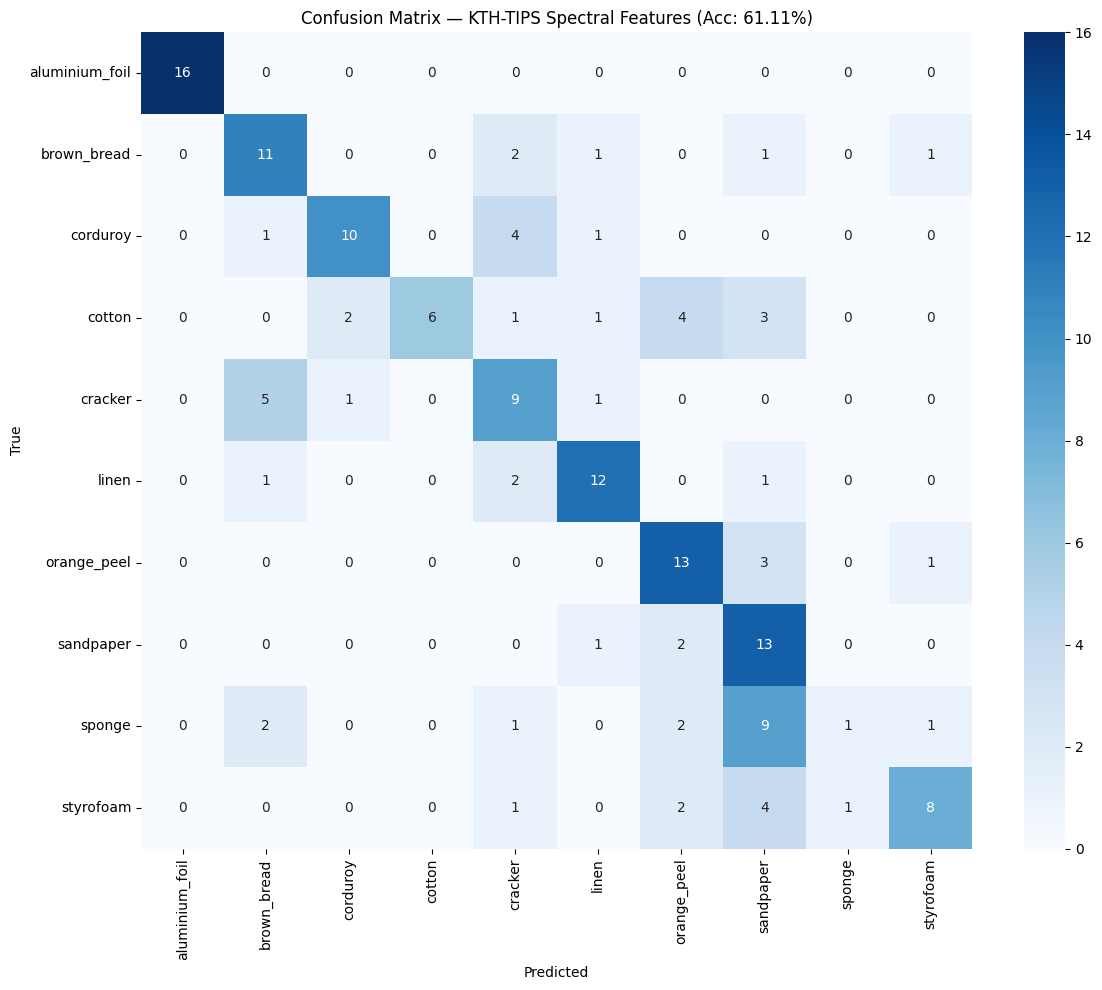


Top 5 Most Accurate Categories:
  aluminium_foil: 100.0%
  sandpaper: 81.2%
  orange_peel: 76.5%
  linen: 75.0%
  brown_bread: 68.8%


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, TensorDataset

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 1. Load model checkpoint
checkpoint = torch.load(
    "/content/drive/My Drive/Final Project (Applied mathmatic)/best_model_kth.pt",
    map_location=device
)
model = TextureSpectralNet(
    input_size=checkpoint['feature_dim'],
    num_classes=len(checkpoint['categories'])
).to(device)
model.load_state_dict(checkpoint['model_state'])
model.eval()
categories = checkpoint['categories']

# 2. Recreate test_loader from cache
dataset_path = "/content/drive/My Drive/Final Project (Applied mathmatic)/KTH-TIPS"
k, n_size = 50, 48
X_all, y_all, _ = prepare_kth_with_cache(dataset_path, k=k, n_size=n_size)

scaler = StandardScaler()
X_scaled_all = scaler.fit_transform(X_all.numpy())
X_tensor_all = torch.tensor(X_scaled_all, dtype=torch.float32)

_, X_te, _, y_te = train_test_split(
    X_tensor_all.numpy(), y_all.numpy(),
    test_size=0.2, random_state=42, stratify=y_all.numpy()
)

test_loader = DataLoader(
    TensorDataset(torch.tensor(X_te, dtype=torch.float32),
                  torch.tensor(y_te, dtype=torch.long)),
    batch_size=64, shuffle=False
)

# 3. Predict on test set
all_preds = []
all_labels = []
with torch.no_grad():
    for bx, by in test_loader:
        bx = bx.to(device)
        outputs = model(bx)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(by.numpy())

# 4. Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, xticklabels=categories, yticklabels=categories,
            annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix — KTH-TIPS Spectral Features (Acc: {checkpoint['best_acc']:.2f}%)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# 5. Top / bottom categories
diag = np.array([cm[i, i] / cm.sum(axis=1)[i] if cm.sum(axis=1)[i] != 0 else 0
                 for i in range(len(categories))])
top5_idx = np.argsort(diag)[-5:]
print("\nTop 5 Most Accurate Categories:")
for idx in reversed(top5_idx):
    print(f"  {categories[idx]}: {diag[idx]*100:.1f}%")

Loading spectral cache...
Spectral: 810 samples, 168 features
Computing classical features for 810 images...
   Checkpoint: 500/810 (61.7%)

Merge: Spectral(168) + Classical(68) = 236
Saved to: /content/drive/My Drive/Final Project (Applied mathmatic)/kth_enriched.npz
Train: 648 | Test: 162 | Features: 236

Device: cpu
=== Training ===
Epoch  10 | Loss: 0.5139 | Acc: 91.4% | LR: 0.000994 ◄ best
Epoch  20 | Loss: 0.3334 | Acc: 92.0% | LR: 0.000976 ◄ best
Epoch  30 | Loss: 0.3081 | Acc: 89.5% | LR: 0.000946
Epoch  40 | Loss: 0.3168 | Acc: 93.8% | LR: 0.000905 ◄ best
Epoch  50 | Loss: 0.3564 | Acc: 91.4% | LR: 0.000854
Epoch  60 | Loss: 0.2154 | Acc: 94.4% | LR: 0.000794 ◄ best
Epoch  70 | Loss: 0.2451 | Acc: 94.4% | LR: 0.000727
Epoch  80 | Loss: 0.2345 | Acc: 95.7% | LR: 0.000655 ◄ best
Epoch  90 | Loss: 0.1817 | Acc: 93.8% | LR: 0.000578
Epoch 100 | Loss: 0.1593 | Acc: 96.3% | LR: 0.000500 ◄ best
Epoch 110 | Loss: 0.2519 | Acc: 95.7% | LR: 0.000422
Epoch 120 | Loss: 0.1612 | Acc: 96.9%

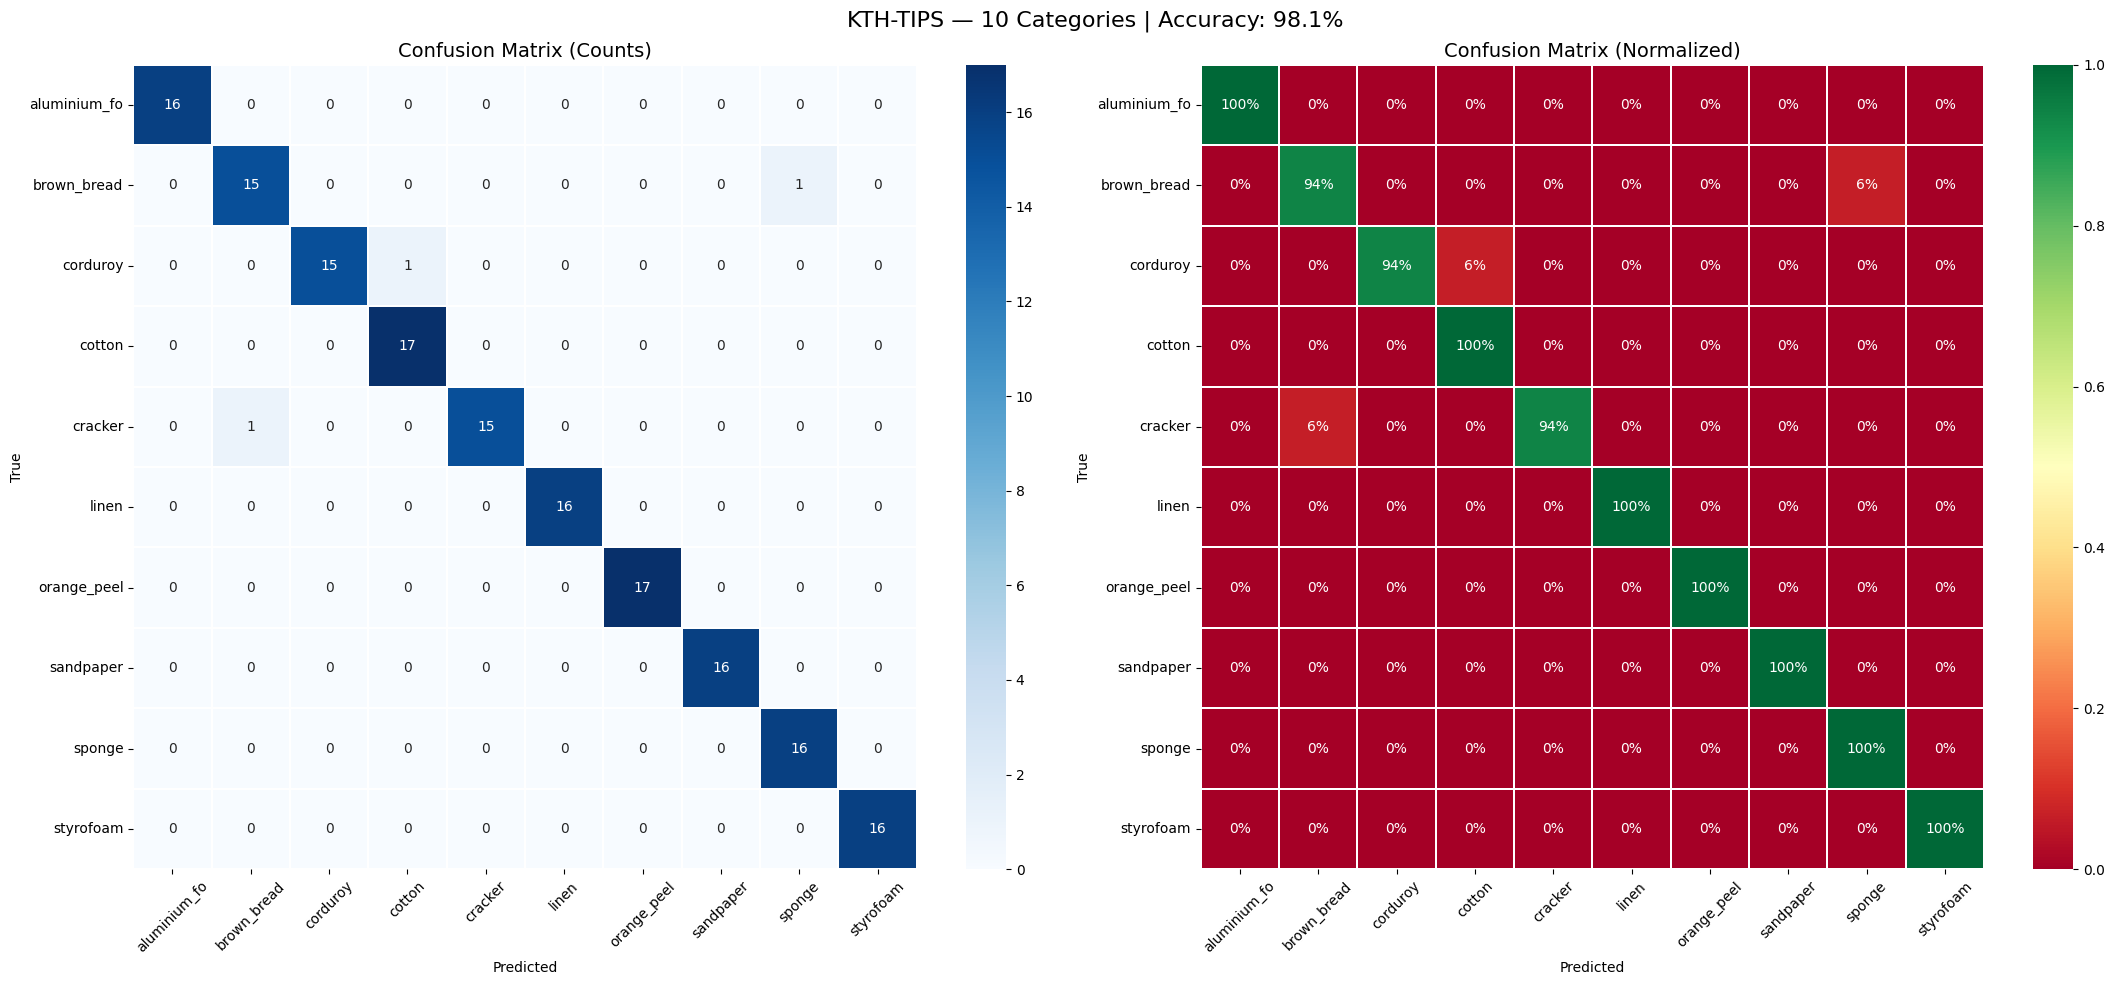

Saved: confusion_matrix_kth.png

Top 5 Best:
  styrofoam            100.0%
  sponge               100.0%
  sandpaper            100.0%
  orange_peel          100.0%
  linen                100.0%

Top 5 Worst:
  brown_bread          93.8%
  corduroy             93.8%
  cracker              93.8%
  aluminium_foil       100.0%
  cotton               100.0%

--- Classification Report ---
                precision    recall  f1-score   support

aluminium_foil       1.00      1.00      1.00        16
   brown_bread       0.94      0.94      0.94        16
      corduroy       1.00      0.94      0.97        16
        cotton       0.94      1.00      0.97        17
       cracker       1.00      0.94      0.97        16
         linen       1.00      1.00      1.00        16
   orange_peel       1.00      1.00      1.00        17
     sandpaper       1.00      1.00      1.00        16
        sponge       0.94      1.00      0.97        16
     styrofoam       1.00      1.00      1.00       

In [ ]:
# ============================================================
# Classical + Color features
# ============================================================
import numpy as np
import cv2
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from skimage.feature import local_binary_pattern
from skimage.feature import graycomatrix, graycoprops
import matplotlib.pyplot as plt
import seaborn as sns

def get_classical_features(img_path, n_size=64):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return np.zeros(26 + 10 + 32)
    img = cv2.resize(img, (n_size, n_size))
    features = []

    # LBP
    try:
        lbp = local_binary_pattern(img, P=24, R=3, method='uniform')
        hist, _ = np.histogram(lbp.ravel(), bins=26, range=(0, 26), density=True)
        features.append(hist)
    except:
        features.append(np.zeros(26))

    # GLCM
    try:
        glcm = graycomatrix(img, distances=[1, 3],
                            angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                            levels=256, symmetric=True, normed=True)
        glcm_feats = []
        for prop in ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation']:
            vals = graycoprops(glcm, prop)
            glcm_feats.extend([vals.mean(), vals.std()])
        features.append(np.array(glcm_feats))
    except:
        features.append(np.zeros(10))

    # Gabor
    try:
        img_f = img.astype(np.float32) / 255.0
        gabor_feats = []
        for freq in [0.1, 0.2, 0.3, 0.4]:
            for theta in [0, np.pi/4, np.pi/2, 3*np.pi/4]:
                kernel = cv2.getGaborKernel(
                    (15, 15), sigma=3.0, theta=theta,
                    lambd=1.0/freq, gamma=0.5, psi=0
                )
                filtered = cv2.filter2D(img_f, cv2.CV_32F, kernel)
                gabor_feats.extend([filtered.mean(), filtered.std()])
        features.append(np.array(gabor_feats))
    except:
        features.append(np.zeros(32))

    return np.concatenate(features)  # 68 features

# ============================================================
# Enrich spectral cache with classical features (KTH-TIPS)
# ============================================================
def enrich_kth_cache_with_classical(
        kth_root,
        spectral_cache_path,
        enriched_cache_path,
        n_size=64):

    print("Loading spectral cache...")
    data = np.load(spectral_cache_path, allow_pickle=True)
    X_spectral      = data['X']
    y               = data['y']
    categories      = list(data['categories'])
    processed_paths = list(data['processed_paths'])

    spectral_dim = X_spectral.shape[1]
    print(f"Spectral: {len(X_spectral)} samples, {spectral_dim} features")

    X_classical_list = []
    start_from = 0

    if os.path.exists(enriched_cache_path):
        enriched = np.load(enriched_cache_path, allow_pickle=True)
        if 'X_combined' in enriched:
            total_combined = enriched['X_combined']
            if len(total_combined) > 0:
                x_class_part = total_combined[:, spectral_dim:]
                X_classical_list = list(x_class_part)
                start_from = len(X_classical_list)
                print(f"Found existing data. Resuming from sample {start_from}")

    remaining = processed_paths[start_from:]
    if len(remaining) == 0:
        print("All features already computed.")
        enriched = np.load(enriched_cache_path, allow_pickle=True)
        return enriched['X_combined'], y, categories

    print(f"Computing classical features for {len(remaining)} images...")
    total = len(processed_paths)

    for i, rel_path in enumerate(remaining):
        # KTH-TIPS: rel_path is "category/filename"
        full_path = os.path.join(kth_root, rel_path)
        classical = get_classical_features(full_path, n_size=n_size)
        X_classical_list.append(classical)

        if (i + 1) % 500 == 0:
            current_class_array = np.array(X_classical_list, dtype=float)
            np.savez(enriched_cache_path,
                     X_combined=np.concatenate([X_spectral[:len(current_class_array)],
                                                current_class_array], axis=1),
                     X_classical=current_class_array,
                     y=y, categories=np.array(categories),
                     processed_paths=np.array(processed_paths))
            done = start_from + i + 1
            print(f"   Checkpoint: {done}/{total} ({100*done/total:.1f}%)")

    X_classical = np.array(X_classical_list, dtype=float)
    X_combined  = np.concatenate([X_spectral, X_classical], axis=1)
    print(f"\nMerge: Spectral({spectral_dim}) + Classical({X_classical.shape[1]}) = {X_combined.shape[1]}")

    np.savez(enriched_cache_path,
             X_combined=X_combined,
             X_classical=X_classical,
             y=y, categories=np.array(categories),
             processed_paths=np.array(processed_paths))

    print(f"Saved to: {enriched_cache_path}")
    return X_combined, y, categories

# ============================================================
# Confusion Matrix helper
# ============================================================
def plot_confusion_matrix(model, test_loader, categories, device):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for bx, by in test_loader:
            bx, by = bx.to(device), by.to(device)
            preds = model(bx).argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(by.cpu().numpy())

    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    cm = confusion_matrix(all_labels, all_preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    short_names = [c[:12] for c in categories]

    fig, axes = plt.subplots(1, 2, figsize=(22, 10))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=short_names, yticklabels=short_names,
                ax=axes[0], linewidths=0.3)
    axes[0].set_title('Confusion Matrix (Counts)', fontsize=14)
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
    axes[0].tick_params(axis='x', rotation=45)

    sns.heatmap(cm_norm, annot=True, fmt='.0%', cmap='RdYlGn',
                xticklabels=short_names, yticklabels=short_names,
                ax=axes[1], linewidths=0.3, vmin=0, vmax=1)
    axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14)
    axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
    axes[1].tick_params(axis='x', rotation=45)

    overall_acc = 100 * np.diag(cm).sum() / cm.sum()
    plt.suptitle(f'KTH-TIPS — {len(categories)} Categories | Accuracy: {overall_acc:.1f}%',
                 fontsize=16)
    plt.tight_layout()
    plt.savefig('confusion_matrix_kth.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: confusion_matrix_kth.png")

    per_class_acc = np.diag(cm_norm)
    print("\nTop 5 Best:")
    for i in np.argsort(per_class_acc)[::-1][:5]:
        print(f"  {categories[i]:<20} {per_class_acc[i]*100:.1f}%")
    print("\nTop 5 Worst:")
    for i in np.argsort(per_class_acc)[:5]:
        print(f"  {categories[i]:<20} {per_class_acc[i]*100:.1f}%")

    print("\n--- Classification Report ---")
    print(classification_report(all_labels, all_preds,
                                target_names=categories, digits=2))
    return cm, per_class_acc

# ============================================================
# Full run (Spectral + Classical + Neural Net) for KTH-TIPS
# ============================================================
kth_root        = "/content/drive/My Drive/Final Project (Applied mathmatic)/KTH-TIPS"
spectral_cache  = "/content/drive/My Drive/Final Project (Applied mathmatic)/kth_features.npz"
enriched_cache  = "/content/drive/My Drive/Final Project (Applied mathmatic)/kth_enriched.npz"

# Step 1: Enrich the spectral cache with classical features
X_combined, y, categories = enrich_kth_cache_with_classical(
    kth_root, spectral_cache, enriched_cache, n_size=64
)

# Step 2: Stratified 80/20 split (KTH-TIPS has no official split files)
data = np.load(enriched_cache, allow_pickle=True)
X_np = data['X_combined']
y_np = data['y']

scaler  = StandardScaler()
X_train_np, X_test_np, y_train_np, y_test_np = train_test_split(
    X_np, y_np, test_size=0.2, random_state=42, stratify=y_np
)
X_train = scaler.fit_transform(X_train_np)
X_test  = scaler.transform(X_test_np)

feature_dim = X_train.shape[1]
num_classes = len(categories)
print(f"Train: {len(X_train)} | Test: {len(X_test)} | Features: {feature_dim}")

# Step 3: DataLoaders
train_loader = DataLoader(
    TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train_np)),
    batch_size=64, shuffle=True
)
test_loader = DataLoader(
    TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test_np)),
    batch_size=64, shuffle=False
)

# Step 4: Train
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model     = TextureSpectralNet(feature_dim, num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=200)

best_acc, best_model_state = 0, None
print(f"\nDevice: {device}")
print("=== Training ===")

for epoch in range(200):
    model.train()
    total_loss = 0
    for bx, by in train_loader:
        bx, by = bx.to(device), by.to(device)
        optimizer.zero_grad()
        loss = criterion(model(bx), by)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    scheduler.step()

    if (epoch + 1) % 10 == 0:
        model.eval()
        correct = total = 0
        with torch.no_grad():
            for bx, by in test_loader:
                bx, by = bx.to(device), by.to(device)
                preds = model(bx).argmax(dim=1)
                correct += (preds == by).sum().item()
                total   += by.size(0)
        acc    = 100 * correct / total
        lr_now = optimizer.param_groups[0]['lr']
        if acc > best_acc:
            best_acc         = acc
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
            marker = " ◄ best"
        else:
            marker = ""
        print(f"Epoch {epoch+1:3d} | Loss: {total_loss/len(train_loader):.4f} "
              f"| Acc: {acc:.1f}% | LR: {lr_now:.6f}{marker}")

# Step 5: Save + Confusion Matrix
model.load_state_dict(best_model_state)
torch.save({
    'model_state': best_model_state,
    'categories':  categories,
    'feature_dim': feature_dim,
    'best_acc':    best_acc,
}, "/content/drive/My Drive/Final Project (Applied mathmatic)/best_model_kth_combined.pt")

print(f"\n{'='*45}")
print(f"Best Accuracy: {best_acc:.2f}%")
print(f"Random baseline: {100/num_classes:.2f}%")

cm, per_class_acc = plot_confusion_matrix(model, test_loader, categories, device)

In [ ]:
def get_color_features(img_path):
    img = cv2.imread(img_path)
    if img is None:
        return np.zeros(6)
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    color_feats = []
    for i in range(3):
        channel = hsv[:,:,i]
        color_feats.extend([channel.mean() / 255.0, channel.std() / 255.0])
    return np.array(color_feats)

# Full enrichment: spectral + classical + color (KTH-TIPS)
def enrich_kth_cache_full(kth_root, spectral_cache_path, enriched_cache_path):
    print("Loading spectral cache...")
    data = np.load(spectral_cache_path, allow_pickle=True)
    X_spectral = data['X']
    processed_paths = data['processed_paths']

    X_extra_list = []
    print(f"Computing Classical + Color features for {len(processed_paths)} images...")
    for i, rel_path in enumerate(processed_paths):
        full_path = os.path.join(kth_root, rel_path)
        classical = get_classical_features(full_path)
        color     = get_color_features(full_path)
        X_extra_list.append(np.concatenate([classical, color]))
        if (i+1) % 200 == 0:
            print(f"  Processed {i+1}/{len(processed_paths)}")

    X_extra = np.array(X_extra_list)
    X_combined = np.concatenate([X_spectral, X_extra], axis=1)
    np.savez(enriched_cache_path, X_combined=X_combined, y=data['y'],
             categories=data['categories'], processed_paths=processed_paths)
    return X_combined, data['y'], data['categories']

In [ ]:
import xgboost as xgb
from sklearn.metrics import accuracy_score

def train_xgboost(X_train, y_train, X_test, y_test, num_classes):
    print("\n--- Training XGBoost ---")
    clf = xgb.XGBClassifier(
        n_estimators=1000,
        max_depth=7,
        learning_rate=0.03,
        subsample=0.8,
        colsample_bytree=0.7,
        tree_method='hist',
        device='cuda' if torch.cuda.is_available() else 'cpu',
        early_stopping_rounds=50,
        objective='multi:softprob',
        random_state=42
    )
    clf.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=100)
    preds = clf.predict(X_test)
    acc = accuracy_score(y_test, preds)
    return clf, acc

# --- Run ---
X_all, y_all, categories = enrich_kth_cache_full(kth_root, spectral_cache, enriched_cache)

# Stratified split
X_train_xgb, X_test_xgb, y_train_xgb, y_test_xgb = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

best_model_xgb, final_acc = train_xgboost(
    X_train_xgb, y_train_xgb, X_test_xgb, y_test_xgb, len(categories)
)
print(f"\nKTH-TIPS Final Accuracy (XGBoost + Color): {final_acc*100:.2f}%")

Loading spectral cache...
Computing Classical + Color features for 810 images...
  Processed 200/810
  Processed 400/810
  Processed 600/810
  Processed 800/810

--- Training XGBoost ---
[0]	validation_0-mlogloss:2.21735
[100]	validation_0-mlogloss:0.43306
[200]	validation_0-mlogloss:0.25653
[300]	validation_0-mlogloss:0.22129
[400]	validation_0-mlogloss:0.21061
[500]	validation_0-mlogloss:0.20795
[600]	validation_0-mlogloss:0.20665
[700]	validation_0-mlogloss:0.20564
[795]	validation_0-mlogloss:0.20550

KTH-TIPS Final Accuracy (XGBoost + Color): 93.21%


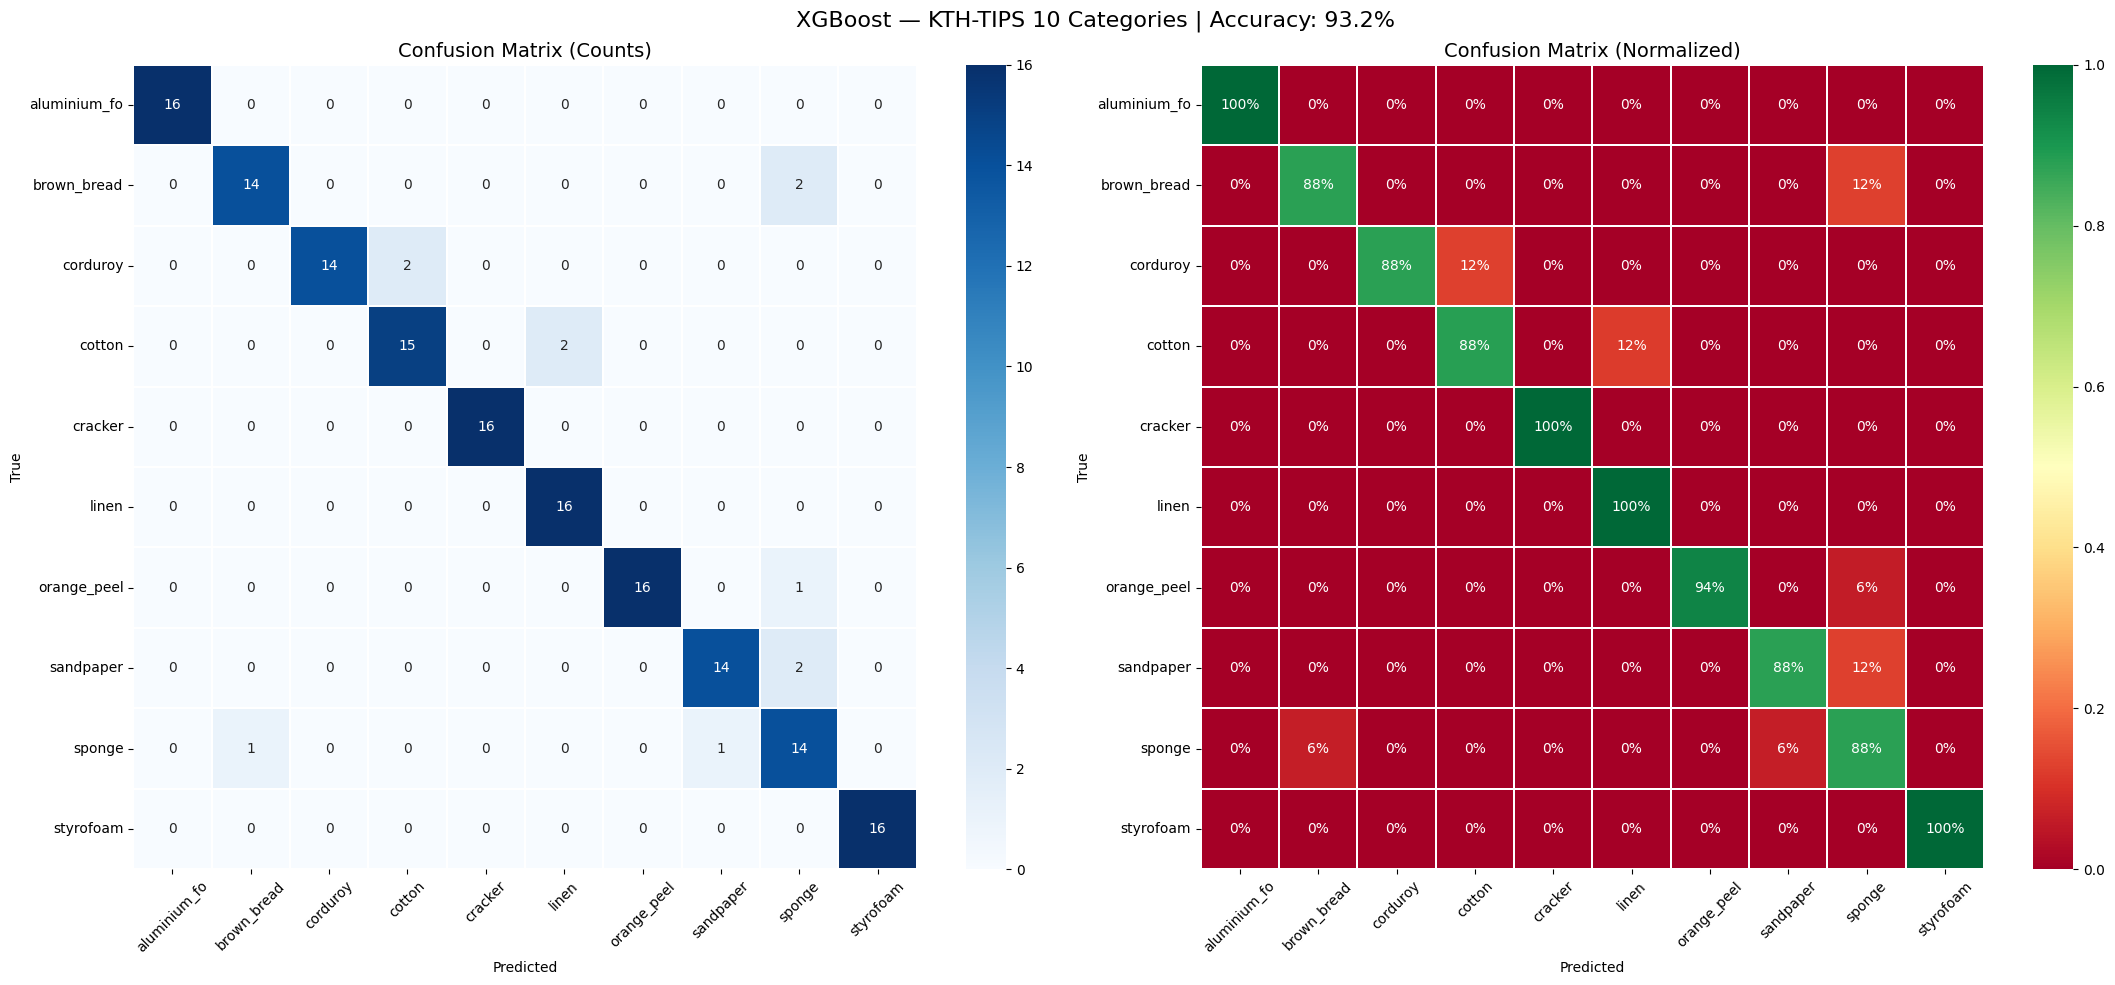

Saved: confusion_matrix_kth_xgboost.png

Top 5 Best:
  styrofoam            100.0%
  cracker              100.0%
  aluminium_foil       100.0%
  linen                100.0%
  orange_peel          94.1%

Top 5 Worst:
  brown_bread          87.5%
  corduroy             87.5%
  sandpaper            87.5%
  sponge               87.5%
  cotton               88.2%

--- Classification Report ---
                precision    recall  f1-score   support

aluminium_foil       1.00      1.00      1.00        16
   brown_bread       0.93      0.88      0.90        16
      corduroy       1.00      0.88      0.93        16
        cotton       0.88      0.88      0.88        17
       cracker       1.00      1.00      1.00        16
         linen       0.89      1.00      0.94        16
   orange_peel       1.00      0.94      0.97        17
     sandpaper       0.93      0.88      0.90        16
        sponge       0.74      0.88      0.80        16
     styrofoam       1.00      1.00      1.00  

(array([[16,  0,  0,  0,  0,  0,  0,  0,  0,  0],
        [ 0, 14,  0,  0,  0,  0,  0,  0,  2,  0],
        [ 0,  0, 14,  2,  0,  0,  0,  0,  0,  0],
        [ 0,  0,  0, 15,  0,  2,  0,  0,  0,  0],
        [ 0,  0,  0,  0, 16,  0,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0, 16,  0,  0,  0,  0],
        [ 0,  0,  0,  0,  0,  0, 16,  0,  1,  0],
        [ 0,  0,  0,  0,  0,  0,  0, 14,  2,  0],
        [ 0,  1,  0,  0,  0,  0,  0,  1, 14,  0],
        [ 0,  0,  0,  0,  0,  0,  0,  0,  0, 16]]),
 array([1.        , 0.875     , 0.875     , 0.88235294, 1.        ,
        1.        , 0.94117647, 0.875     , 0.875     , 1.        ]))

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

def plot_confusion_matrix_xgboost(model, X_test, y_test, categories):
    all_preds  = model.predict(X_test)
    all_labels = y_test

    cm = confusion_matrix(all_labels, all_preds)
    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.zeros_like(cm, dtype=float)
    non_zero_rows = row_sums.flatten() != 0
    cm_norm[non_zero_rows] = cm[non_zero_rows].astype(float) / row_sums[non_zero_rows]

    short_names = [c[:12] for c in categories]
    fig, axes = plt.subplots(1, 2, figsize=(22, 10))

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=short_names, yticklabels=short_names,
                ax=axes[0], linewidths=0.3)
    axes[0].set_title('Confusion Matrix (Counts)', fontsize=14)
    axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
    axes[0].tick_params(axis='x', rotation=45)

    sns.heatmap(cm_norm, annot=True, fmt='.0%', cmap='RdYlGn',
                xticklabels=short_names, yticklabels=short_names,
                ax=axes[1], linewidths=0.3, vmin=0, vmax=1)
    axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14)
    axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
    axes[1].tick_params(axis='x', rotation=45)

    overall_acc = 100 * np.diag(cm).sum() / cm.sum()
    plt.suptitle(f'XGBoost — KTH-TIPS {len(categories)} Categories | Accuracy: {overall_acc:.1f}%',
                 fontsize=16)
    plt.tight_layout()
    plt.savefig('confusion_matrix_kth_xgboost.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Saved: confusion_matrix_kth_xgboost.png")

    per_class_acc = np.zeros(len(categories))
    for i in range(len(categories)):
        if row_sums[i] != 0:
            per_class_acc[i] = cm_norm[i, i]

    num_show = min(5, len(categories))
    print("\nTop 5 Best:")
    for i in np.argsort(per_class_acc)[::-1][:num_show]:
        print(f"  {categories[i]:<20} {per_class_acc[i]*100:.1f}%")
    print("\nTop 5 Worst:")
    for i in np.argsort(per_class_acc)[:num_show]:
        print(f"  {categories[i]:<20} {per_class_acc[i]*100:.1f}%")

    print("\n--- Classification Report ---")
    print(classification_report(all_labels, all_preds,
                                target_names=categories, digits=2))
    return cm, per_class_acc

plot_confusion_matrix_xgboost(best_model_xgb, X_test_xgb, y_test_xgb, categories)

In [ ]:
# ============================================================
# Compact all-in-one pipeline: spectral + classical + color + XGBoost
# (same as the compact last cell in the DTD notebook, adapted for KTH-TIPS)
# ============================================================
import numpy as np
import cv2
import os
import glob
import torch
import xgboost as xgb
from scipy.spatial.distance import pdist, squareform
from scipy.sparse.linalg import eigsh
from skimage.feature import local_binary_pattern, graycomatrix, graycoprops
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

def extract_spectral_features(img_path, k=50, n_size=32):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None: return np.zeros(k + 6)
    img = cv2.resize(img, (n_size, n_size))
    pixels = img.flatten().reshape(-1, 1) / 255.0
    dist_sq = squareform(pdist(pixels, 'sqeuclidean'))
    W = np.exp(-dist_sq / (2 * 0.05**2))
    D = np.diag(np.sum(W, axis=1))
    L = D - W
    try:
        vals = eigsh(L, k=k, which='SM', return_eigenvectors=False)
        vals = np.sort(vals)
    except:
        vals = np.zeros(k)
    stats = [np.mean(vals), np.std(vals), np.median(vals),
             np.min(vals), np.max(vals), np.ptp(vals)]
    return np.concatenate([vals, stats])

def get_classical_and_color_features(img_path, n_size=64):
    img_bgr = cv2.imread(img_path)
    if img_bgr is None: return np.zeros(68 + 6)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    img_gray = cv2.resize(img_gray, (n_size, n_size))
    features = []
    # LBP
    lbp = local_binary_pattern(img_gray, P=24, R=3, method='uniform')
    hist, _ = np.histogram(lbp.ravel(), bins=26, range=(0, 26), density=True)
    features.append(hist)
    # GLCM
    glcm = graycomatrix(img_gray, distances=[1, 3],
                        angles=[0, np.pi/4, np.pi/2, 3*np.pi/4],
                        levels=256, symmetric=True, normed=True)
    glcm_feats = []
    for prop in ['contrast', 'dissimilarity', 'homogeneity', 'energy', 'correlation']:
        vals = graycoprops(glcm, prop)
        glcm_feats.extend([vals.mean(), vals.std()])
    features.append(np.array(glcm_feats))
    # Gabor
    img_f = img_gray.astype(np.float32) / 255.0
    gabor_feats = []
    for freq in [0.1, 0.2, 0.3, 0.4]:
        for theta in [0, np.pi/4, np.pi/2, 3*np.pi/4]:
            kernel = cv2.getGaborKernel((15, 15), sigma=3.0, theta=theta,
                                        lambd=1.0/freq, gamma=0.5, psi=0)
            filtered = cv2.filter2D(img_f, cv2.CV_32F, kernel)
            gabor_feats.extend([filtered.mean(), filtered.std()])
    features.append(np.array(gabor_feats))
    # Color HSV
    hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
    color_stats = []
    for i in range(3):
        channel = hsv[:,:,i]
        color_stats.extend([channel.mean() / 255.0, channel.std() / 255.0])
    features.append(np.array(color_stats))
    return np.concatenate(features)

# ============================================================
# KTH-TIPS dataset preparation
# ============================================================
def prepare_kth_dataset(kth_root):
    all_features = []
    all_labels   = []
    categories   = sorted([d for d in os.listdir(kth_root)
                            if os.path.isdir(os.path.join(kth_root, d))])
    print(f"Found {len(categories)} categories in KTH-TIPS: {categories}")

    for idx, cat in enumerate(categories):
        cat_path  = os.path.join(kth_root, cat)
        img_files = glob.glob(os.path.join(cat_path, "*.png")) + \
                    glob.glob(os.path.join(cat_path, "*.jpg"))
        print(f"  Processing {cat:<20} | Images: {len(img_files)}")
        for img_p in img_files:
            try:
                spec  = extract_spectral_features(img_p)
                extra = get_classical_and_color_features(img_p)
                all_features.append(np.concatenate([spec, extra]))
                all_labels.append(idx)
            except:
                continue

    return np.array(all_features), np.array(all_labels), categories

# --- Run ---
kth_path = "/content/drive/My Drive/Final Project (Applied mathmatic)/KTH-TIPS"
X_kth, y_kth, kth_cats = prepare_kth_dataset(kth_path)

X_train, X_test, y_train, y_test = train_test_split(
    X_kth, y_kth, test_size=0.2, random_state=42, stratify=y_kth
)

clf = xgb.XGBClassifier(
    n_estimators=500, max_depth=6, tree_method='hist',
    device='cuda' if torch.cuda.is_available() else 'cpu',
    random_state=42
)
clf.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=100)
print(f"\nKTH-TIPS Final Accuracy (compact): {accuracy_score(y_test, clf.predict(X_test))*100:.2f}%")

Found 10 categories in KTH-TIPS: ['aluminium_foil', 'brown_bread', 'corduroy', 'cotton', 'cracker', 'linen', 'orange_peel', 'sandpaper', 'sponge', 'styrofoam']
  Processing aluminium_foil       | Images: 81
  Processing brown_bread          | Images: 81
  Processing corduroy             | Images: 81
  Processing cotton               | Images: 81
  Processing cracker              | Images: 81
  Processing linen                | Images: 81
  Processing orange_peel          | Images: 81
  Processing sandpaper            | Images: 81
  Processing sponge               | Images: 81
  Processing styrofoam            | Images: 81
[0]	validation_0-mlogloss:1.46935
[100]	validation_0-mlogloss:0.28678
[200]	validation_0-mlogloss:0.29074
[300]	validation_0-mlogloss:0.29244
[400]	validation_0-mlogloss:0.29219
[499]	validation_0-mlogloss:0.29219

KTH-TIPS Final Accuracy (compact): 91.36%


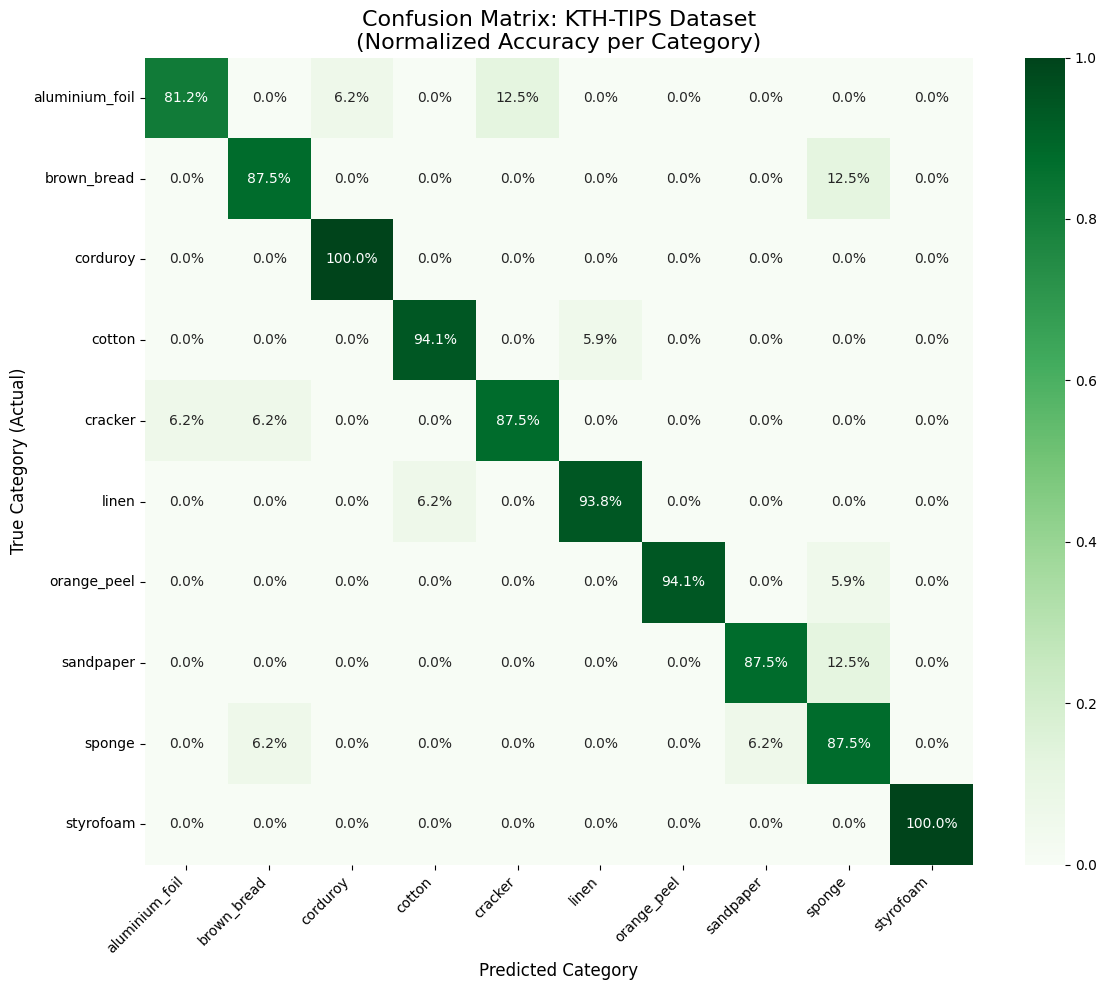

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

def plot_kth_confusion_matrix(model, X_test, y_test, categories):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(12, 10))
    sns.heatmap(cm_normalized, annot=True, fmt='.1%', cmap='Greens',
                xticklabels=categories, yticklabels=categories)
    plt.title('Confusion Matrix: KTH-TIPS Dataset\n(Normalized Accuracy per Category)',
              fontsize=16)
    plt.ylabel('True Category (Actual)', fontsize=12)
    plt.xlabel('Predicted Category', fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

plot_kth_confusion_matrix(clf, X_test, y_test, kth_cats)